# Empirical approximation ratios on synthetic blobs

In [ ]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_blobs

from algorithms.coreset import coreset_kmeans, lightweight_coreset
from algorithms.exact import bench_exact_kmeans, exact_kmeans
from algorithms.lloyd import k_means_plus_plus, lloyds_algorithm
from algorithms.local_search import local_search_kmeans

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
k_values = [2, 3, 4, 5, 6]
n_total = 40
n_runs = 15
d = 4
g = lambda k: 2 * k

def kpp_seed_cost(X, k):
    seeds = k_means_plus_plus(X, k)
    d2 = ((X[:, None, :] - seeds[None, :, :]) ** 2).sum(-1)
    return seeds, None, [d2.min(axis=1).sum()]

algorithms = {
    "k-means++ seeds only":   kpp_seed_cost,
    "Lloyd (k-means++ init)": lloyds_algorithm,
    "Local search (1-swap)":  local_search_kmeans,
}
colors = {
    "k-means++ seeds only":   "tab:blue",
    "Lloyd (k-means++ init)": "tab:orange",
    "Local search (1-swap)":  "tab:green",
}

datasets = {(k, run): make_blobs(n_samples=n_total, centers=g(k), n_features=d,
                                   cluster_std=1, random_state=run)[0]
            for k in k_values for run in range(n_runs)}

# One process per call, 1 OMP thread each — better than OpenMP-within-call
# because per-call DFS trees are small.
keys = list(datasets)
print(f"computing {len(keys)} OPTs in parallel...")
opt_out = bench_exact_kmeans([(datasets[key], key[0]) for key in keys], omp_threads=1)
opts = {key: cost for key, (_, _, cost) in zip(keys, opt_out)}

ratios = {name: [] for name in algorithms}
for k in k_values:
    per_k = {name: [] for name in algorithms}
    for run in range(n_runs):
        X = datasets[(k, run)]
        for name, algo in algorithms.items():
            per_k[name].append(algo(X, k)[2][-1] / opts[(k, run)])
    for name in algorithms:
        ratios[name].append(per_k[name])

print(f"\nparams: σ=1, d={d}, g_true=2k, n={n_total}, {n_runs} runs/k")
print(f"\n{'algorithm':<24} {'k':>2}  {'mean':>6}  {'worst':>6}  {'bound':>8}")
for name in algorithms:
    bound = (lambda k: 8 * (np.log(k) + 2)) if name != "Local search (1-swap)" else (lambda k: 9.0)
    for k, rs in zip(k_values, ratios[name]):
        print(f"{name:<24} {k:>2}  {np.mean(rs):>6.3f}  {np.max(rs):>6.3f}  {bound(k):>8.2f}")

computing 75 OPTs in parallel...

params: σ=1, d=2, g_true=2k, n=40, 15 runs/k

algorithm                 k    mean   worst     bound
k-means++ seeds only      2   1.821   2.314     21.55
k-means++ seeds only      3   3.144  11.218     24.79
k-means++ seeds only      4   2.453   4.624     27.09
k-means++ seeds only      5   2.162   3.118     28.88
k-means++ seeds only      6   2.394   3.826     30.33
Lloyd (k-means++ init)    2   1.043   1.393     21.55
Lloyd (k-means++ init)    3   1.025   1.137     24.79
Lloyd (k-means++ init)    4   1.058   1.358     27.09
Lloyd (k-means++ init)    5   1.173   1.481     28.88
Lloyd (k-means++ init)    6   1.139   1.432     30.33
Local search (1-swap)     2   1.222   1.474      9.00
Local search (1-swap)     3   1.126   1.258      9.00
Local search (1-swap)     4   1.184   1.322      9.00
Local search (1-swap)     5   1.171   1.353      9.00
Local search (1-swap)     6   1.226   1.382      9.00


## Figure 1

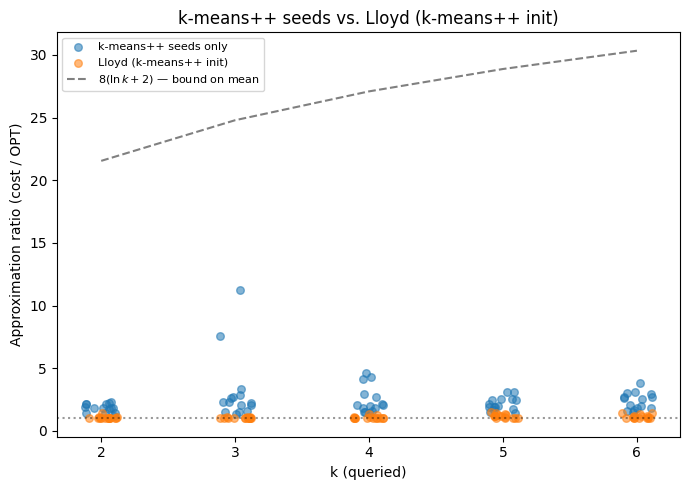

In [ ]:
jitter = np.random.default_rng(0)
fig, ax = plt.subplots(figsize=(7, 5))
for name in ("k-means++ seeds only", "Lloyd (k-means++ init)"):
    for k, rs in zip(k_values, ratios[name]):
        xs = k + jitter.uniform(-0.12, 0.12, size=len(rs))
        ax.scatter(xs, rs, color=colors[name], alpha=0.55, s=30,
                   label=name if k == k_values[0] else None)
ax.plot(k_values, [8 * (np.log(k) + 2) for k in k_values], "--", color="gray",
        label=r"$8(\ln k + 2)$ — bound on mean")
ax.axhline(y=1, linestyle=":", color="black", alpha=0.4)
ax.set_xlabel("k")
ax.set_ylabel("Approximation ratio (cost / OPT)")
ax.set_title("k-means++ seeds vs. Lloyd (k-means++ init)")
ax.set_xticks(k_values)
ax.legend(fontsize=8, loc="upper left")
plt.tight_layout()
plt.show()

## Figure 3

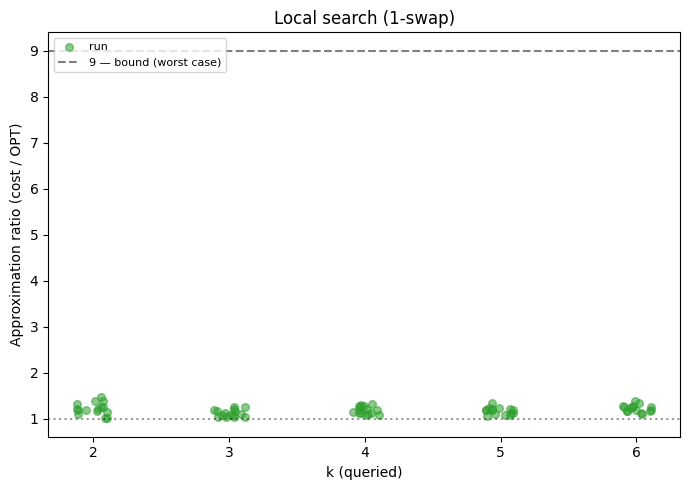

In [ ]:
jitter = np.random.default_rng(0)
name = "Local search (1-swap)"
fig, ax = plt.subplots(figsize=(7, 5))
for k, rs in zip(k_values, ratios[name]):
    xs = k + jitter.uniform(-0.12, 0.12, size=len(rs))
    ax.scatter(xs, rs, color=colors[name], alpha=0.55, s=30,
               label="run" if k == k_values[0] else None)
ax.axhline(y=9, linestyle="--", color="gray", label="9 — bound (worst case)")
ax.axhline(y=1, linestyle=":", color="black", alpha=0.4)
ax.set_xlabel("k")
ax.set_ylabel("Approximation ratio (cost / OPT)")
ax.set_title(name)
ax.set_xticks(k_values)
ax.legend(fontsize=8, loc="upper left")
plt.tight_layout()
plt.show()

## Figure 4

k=6, n=80, d=4, 15 runs, Lloyd mean ratio = 1.764
V = Var(X)/OPT ≈ 31.83, α = 30.33, ε quantile = 0.95

   m    ε_emp   BLK bound   mean ratio    worst
   5    0.601      484.29       17.210   31.966
  10    0.429      318.94        6.934   24.480
  15    0.372      272.06        3.454    7.990
  20    0.307      221.84        3.473   18.209
  25    0.287      207.24        1.952    5.807
  30    0.272      196.52        2.303    4.765
  35    0.248      180.22        2.509    6.049


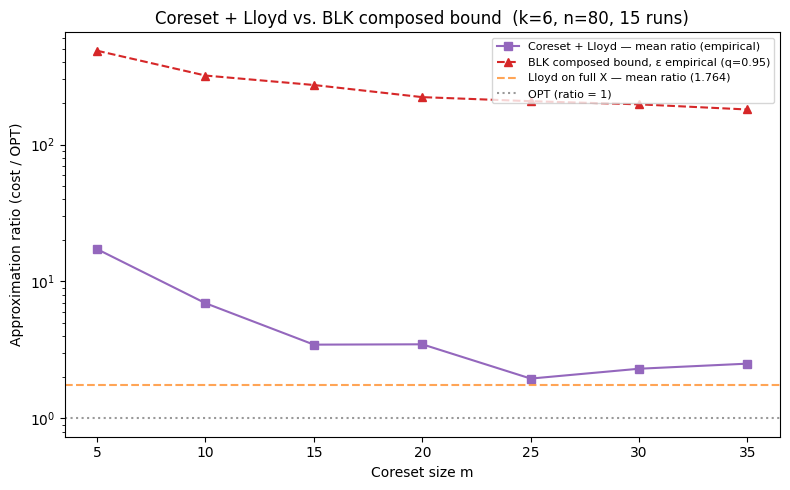

In [ ]:
k_fixed = 6
n_total_c = 80
n_runs_c = 15
d_c = 4
m_values = [5, 10, 15, 20, 25, 30, 35]
quantile = 0.95
n_eps_coresets = 20
alpha = 8 * (np.log(k_fixed) + 2)

def blk_bound(eps, alpha, V):
    """Composed BLK bound on E[cost(X, C*)/OPT]."""
    if eps >= 2:
        return np.inf
    return (alpha * (1 + eps / 2) + (eps / 2) * (alpha + 1) * V) / (1 - eps / 2)


def cost_w(P, C, w=None):
    d2 = ((P[:, None, :] - C[None, :, :]) ** 2).sum(-1).min(1)
    return d2.sum() if w is None else (w * d2).sum()

rng = np.random.default_rng(0)
ratios_by_m = {m: [] for m in m_values}
devs_by_m = {m: [] for m in m_values}
lloyd_ratios, V_per_run = [], []

for run in range(n_runs_c):
    X_c, _ = make_blobs(n_samples=n_total_c, centers=k_fixed, n_features=d_c,
                         cluster_std=1, random_state=run)
    _, _, opt_c = exact_kmeans(X_c, k_fixed)
    var_X = ((X_c - X_c.mean(0)) ** 2).sum()
    V_per_run.append(var_X / opt_c)

    lloyd_centers, _, lloyd_wcss = lloyds_algorithm(X_c, k_fixed)
    lloyd_ratios.append(lloyd_wcss[-1] / opt_c)

    cand = [X_c[rng.choice(n_total_c, k_fixed, replace=False)] for _ in range(20)]
    cand.append(lloyd_centers)
    cX_list = [cost_w(X_c, C) for C in cand]

    for m in m_values:
        ratios_by_m[m].append(coreset_kmeans(X_c, k_fixed, m)[2][-1] / opt_c)
        for _ in range(n_eps_coresets):
            S, w = lightweight_coreset(X_c, m, rng=rng)
            for C, cX in zip(cand, cX_list):
                devs_by_m[m].append(abs(cX - cost_w(S, C, w)) / (cX + var_X))

mean_ratios = [float(np.mean(ratios_by_m[m])) for m in m_values]
worst_ratios = [float(np.max(ratios_by_m[m])) for m in m_values]
lloyd_mean_ratio = float(np.mean(lloyd_ratios))
V_mean = float(np.mean(V_per_run))
eps_emp = [2 * float(np.quantile(devs_by_m[m], quantile)) for m in m_values]
bound_curve = [blk_bound(e, alpha, V_mean) for e in eps_emp]

print(f"k={k_fixed}, n={n_total_c}, d={d_c}, {n_runs_c} runs, "
      f"Lloyd mean ratio = {lloyd_mean_ratio:.3f}")
print(f"V = Var(X)/OPT ≈ {V_mean:.2f}, α = {alpha:.2f}, ε quantile = {quantile}")
print(f"\n{'m':>4}  {'ε_emp':>7}  {'BLK bound':>10}  {'mean ratio':>11}  {'worst':>7}")
for m, e, b, r, wr in zip(m_values, eps_emp, bound_curve, mean_ratios, worst_ratios):
    b_str = f"{b:>10.2f}" if np.isfinite(b) else f"{'vacuous':>10}"
    print(f"{m:>4}  {e:>7.3f}  {b_str}  {r:>11.3f}  {wr:>7.3f}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(m_values, mean_ratios, marker="s", color="tab:purple",
        label="Coreset + Lloyd — mean ratio (empirical)")
finite = [(m, b) for m, b in zip(m_values, bound_curve) if np.isfinite(b)]
if finite:
    ms_b, bs = zip(*finite)
    ax.plot(ms_b, bs, marker="^", linestyle="--", color="tab:red",
            label=fr"BLK composed bound, ε empirical (q={quantile})")
ax.axhline(y=lloyd_mean_ratio, linestyle="--", color="tab:orange", alpha=0.7,
           label=f"Lloyd on full X — mean ratio ({lloyd_mean_ratio:.3f})")
ax.axhline(y=1, linestyle=":", color="black", alpha=0.4, label="OPT (ratio = 1)")
ax.set_xlabel("Coreset size m")
ax.set_ylabel("Approximation ratio (cost / OPT)")
ax.set_yscale("log")
ax.set_title(f"Coreset + Lloyd vs. BLK composed bound  "
             f"(k={k_fixed}, n={n_total_c}, {n_runs_c} runs)")
ax.legend(fontsize=8, loc="upper right")
plt.tight_layout()
plt.show()